# NLP Analysis: Public Discourse on AI-Generated Art (YouTube Comments)

This notebook covers:
1. Setup & Data Loading
2. Word Frequency & TF-IDF Exploration
3. Sentiment Analysis (VADER + deeper breakdown)
4. LDA Topic Modelling with Coherence-Based Tuning
5. Pro-AI vs Anti-AI Comparison (topics + sentiment)


---
## 1. Setup & Data Loading

In [1]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from pathlib import Path

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import pyLDAvis
from wordcloud import WordCloud

warnings.filterwarnings('ignore')
pyLDAvis.enable_notebook()

# download NLTK data
for resource in ['stopwords', 'wordnet', 'omw-1.4', 'punkt']:
    nltk.download(resource, quiet=True)

# plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('All imports successful.')

All imports successful.


In [2]:
DATA_PATH = Path('../data_clean/comments_master_processed_balanced.csv')
OUTPUT_DIR = Path('../outputs/nlp')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)

# basic sanity check
print(f'Loaded {len(df):,} rows')
print(f'Columns: {list(df.columns)}')
print(f"\nVideo type distribution:")
print(df['video_type'].value_counts())

Loaded 20,022 rows
Columns: ['video_id', 'video_type', 'video_source_value', 'video_title', 'channel_name', 'video_published_at', 'video_view_count', 'video_comment_count', 'comment_id', 'parent_id', 'is_reply', 'author', 'author_channel_id', 'parent_author_channel_id', 'comment_text', 'published_at', 'updated_at', 'like_count', 'total_reply_count', 'collection_timestamp', 'cleaned_text', 'tokens', 'tokens_filtered', 'tokens_str']

Video type distribution:
video_type
AI       10011
Human    10011
Name: count, dtype: int64


In [3]:
# relabel video types for clarity
df["video_type"] = df["video_type"].replace({
    "AI": "Pro-AI",
    "Human": "Anti-AI"
})

print(df["video_type"].value_counts())

video_type
Pro-AI     10011
Anti-AI    10011
Name: count, dtype: int64


In [4]:
# extra cleaning for LDA
lemmatizer = WordNetLemmatizer()

BASE_STOP = set(stopwords.words('english'))
CUSTOM_STOP = {
    'one', 'also', 'time', 'much', 'would', 'get', 'got', 'like', 'just',
    'really', 'thing', 'things', 'know', 'think', 'still', 'make', 'made',
    'use', 'using', 'want', 'comment', 'video', 'people', 'person',
    'something', 'anything', 'even', 'way', 'see', 'could', 'actually',
    'good', 'right', 'well', 'say', 'said', 'dont', 'doesnt', 'im',
    'youre', 'lol', 'omg', 'yeah', 'ok', 'guys', 'man', 'dude', 'bro',
    'going', 'come', 'back', 'watch', 'watching', 'channel', 'subscribe'
}
STOP_WORDS = BASE_STOP | CUSTOM_STOP


def clean_for_lda(text: str) -> str:
    """Aggressive cleaning for topic modelling."""
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)   
    text = re.sub(r'@\w+|#\w+', '', text)               
    text = re.sub(r'[^a-z\s]', ' ', text)               
    tokens = [
        lemmatizer.lemmatize(w)
        for w in text.split()
        if w not in STOP_WORDS and len(w) > 2
    ]
    return ' '.join(tokens)


df['cleaned'] = df['comment_text'].apply(clean_for_lda)
df = df[df['cleaned'].str.strip().ne('')].reset_index(drop=True)

In [5]:
proai_df = df[df["video_type"].eq("Pro-AI")].copy()
antiai_df = df[df["video_type"].eq("Anti-AI")].copy()

print(
    f"After cleaning: {len(df):,} comments  |  "
    f"Pro-AI: {len(proai_df):,}  Anti-AI: {len(antiai_df):,}"
)

After cleaning: 19,334 comments  |  Pro-AI: 9,591  Anti-AI: 9,743


---
## 2. Word Frequency & TF-IDF Exploration

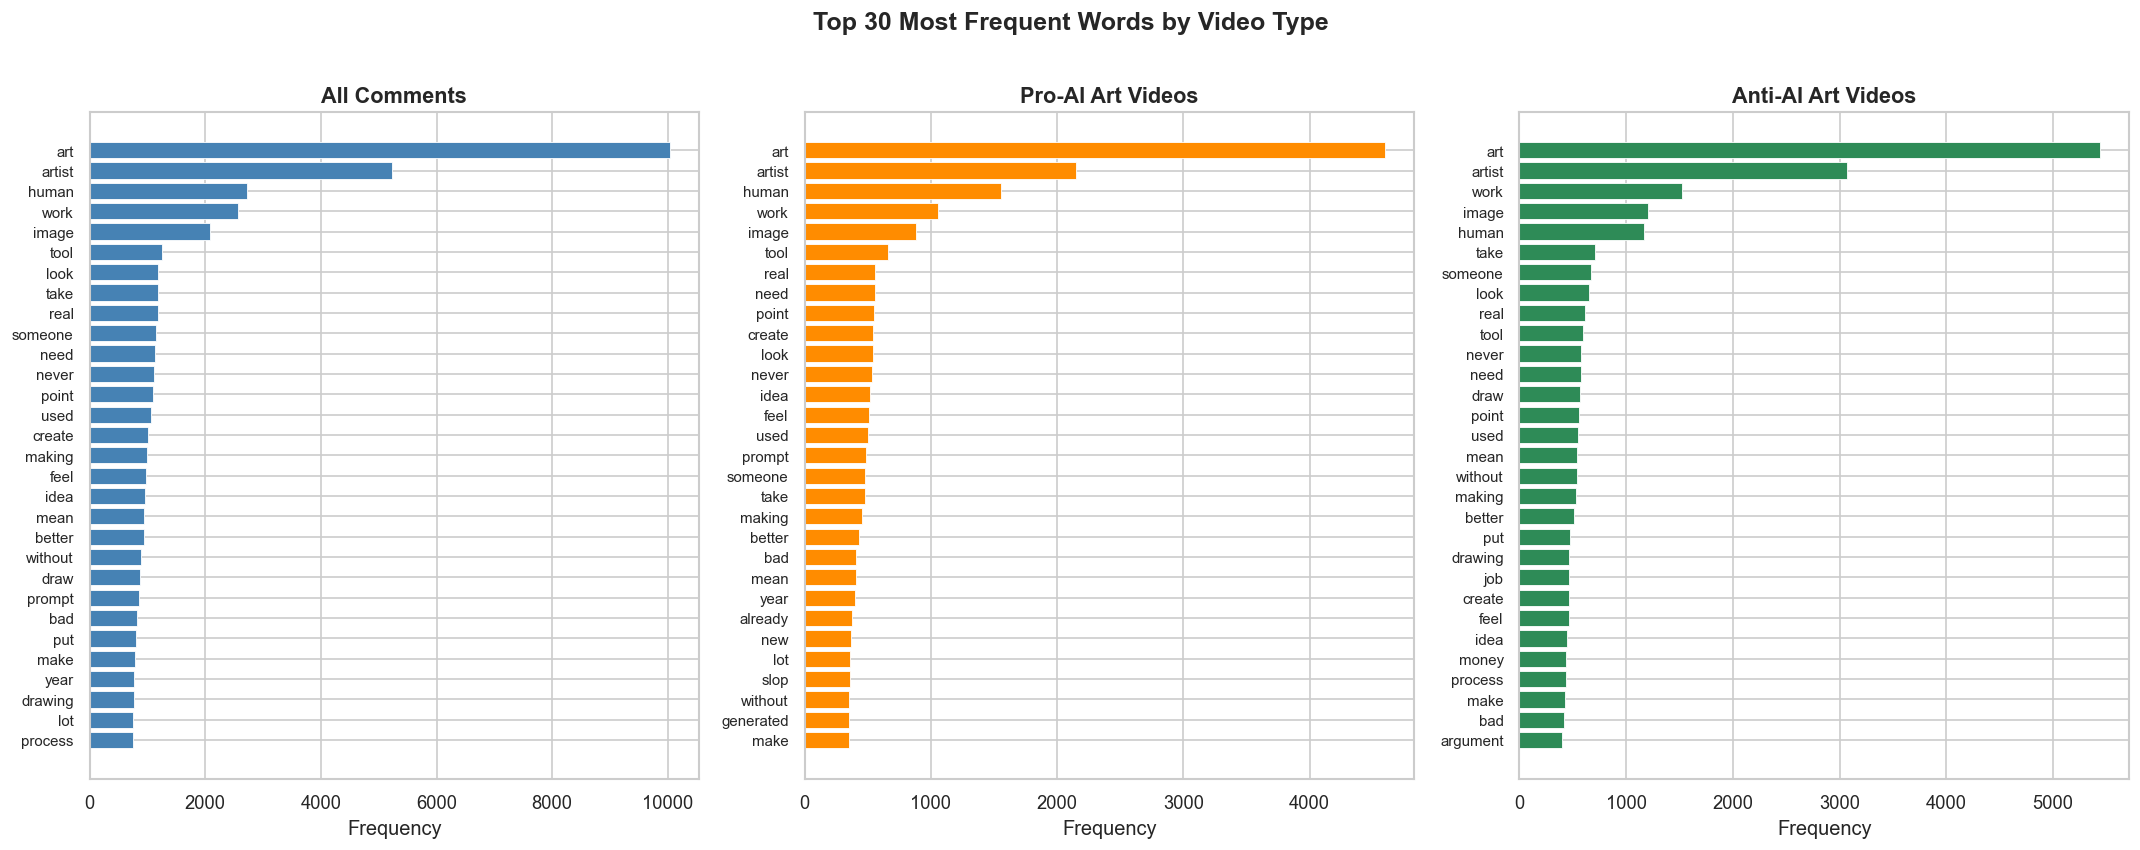

Saved: word_frequency_comparison.png


In [6]:
# top word frequencies
def top_n_words(texts: pd.Series, n: int = 30) -> pd.DataFrame:
    """Count unigram frequencies across a Series of cleaned strings."""
    all_tokens = ' '.join(texts).split()
    counts = Counter(all_tokens)
    return pd.DataFrame(counts.most_common(n), columns=['word', 'count'])


freq_overall = top_n_words(df['cleaned'], 30)
freq_ai      = top_n_words(proai_df['cleaned'], 30)
freq_human   = top_n_words(antiai_df['cleaned'], 30)

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, freq, title, color in zip(
    axes,
    [freq_overall, freq_ai, freq_human],
    ['All Comments', 'Pro-AI Art Videos', 'Anti-AI Art Videos'],
    ['steelblue', 'darkorange', 'seagreen']
):
    ax.barh(freq['word'][::-1], freq['count'][::-1], color=color, edgecolor='white', linewidth=0.5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Frequency')
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('Top 30 Most Frequent Words by Video Type', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'word_frequency_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: word_frequency_comparison.png')

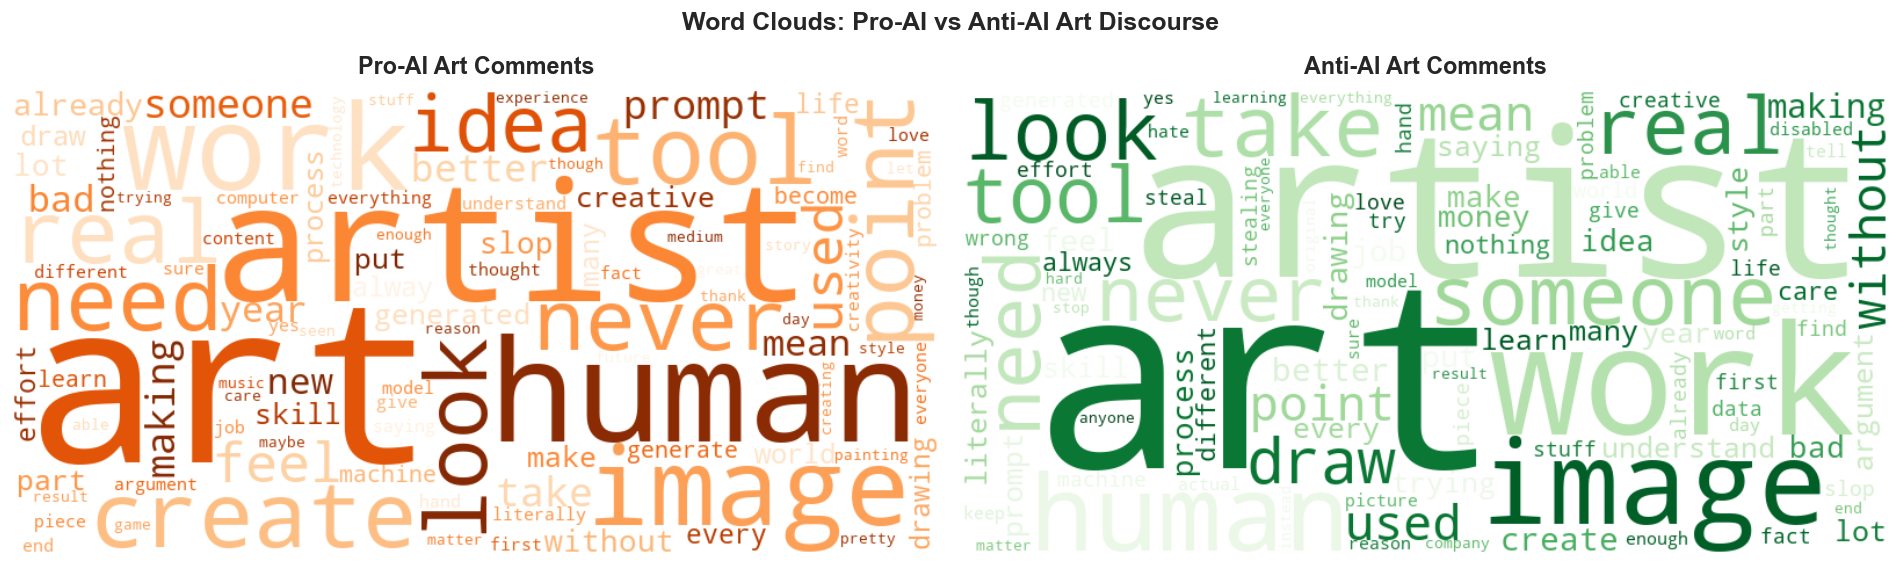

Saved: wordclouds_ai_vs_human.png


In [7]:
# word clouds
def make_wordcloud(texts: pd.Series, title: str, colormap: str, ax):
    text_blob = ' '.join(texts)
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=colormap,
        max_words=100,
        collocations=False
    ).generate(text_blob)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)


fig, axes = plt.subplots(1, 2, figsize=(16, 5))
make_wordcloud(proai_df['cleaned'],    'Pro-AI Art Comments',    'Oranges',  axes[0])
make_wordcloud(antiai_df['cleaned'], 'Anti-AI Art Comments', 'Greens',   axes[1])
plt.suptitle('Word Clouds: Pro-AI vs Anti-AI Art Discourse', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'wordclouds_ai_vs_human.png', bbox_inches='tight')
plt.show()
print('Saved: wordclouds_ai_vs_human.png')

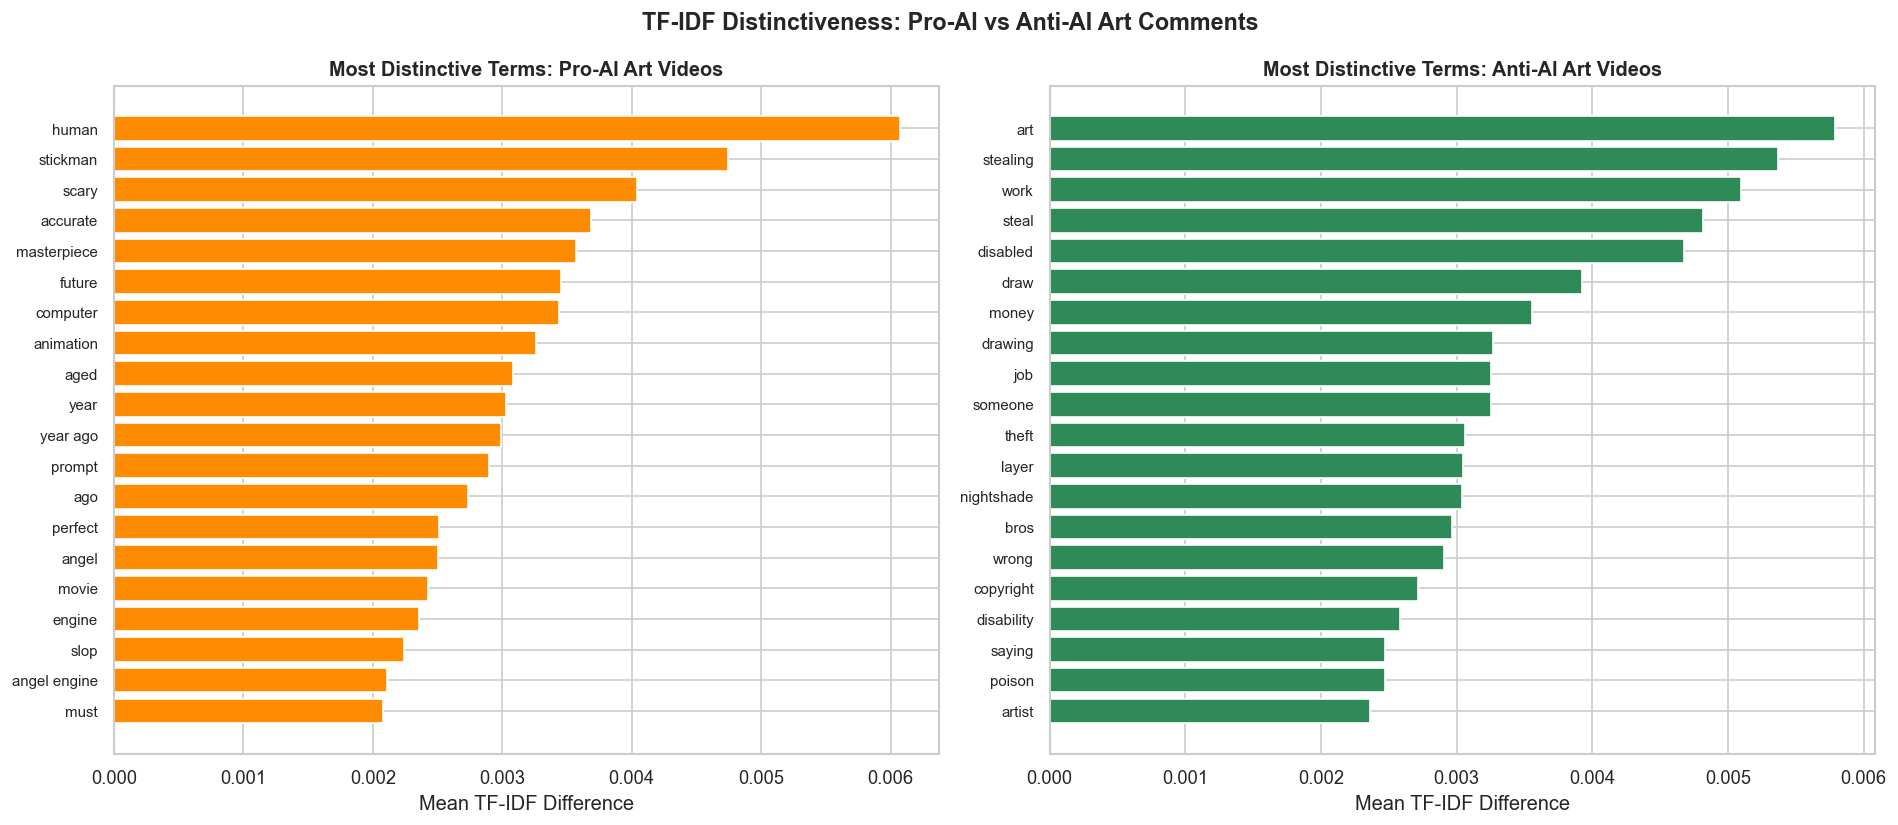

Saved: tfidf_distinctive_terms.png

Top 10 AI-distinctive terms:
       term    score
      human 0.006069
   stickman 0.004746
      scary 0.004044
   accurate 0.003686
masterpiece 0.003570
     future 0.003455
   computer 0.003440
  animation 0.003257
       aged 0.003083
       year 0.003025

Top 10 Human-distinctive terms:
    term    score
     art 0.005791
stealing 0.005369
    work 0.005094
   steal 0.004817
disabled 0.004672
    draw 0.003922
   money 0.003554
 drawing 0.003265
     job 0.003250
 someone 0.003249


In [8]:
# tf-idf distinctiveness
tfidf = TfidfVectorizer(
    max_df=0.85,
    min_df=10,
    ngram_range=(1, 2),
    max_features=5000
)

tfidf_matrix = tfidf.fit_transform(df['cleaned'])
feature_names = tfidf.get_feature_names_out()

proai_mask    = df['video_type'].eq('Pro-AI').values
antiai_mask = df['video_type'].eq('Anti-AI').values

proai_mean    = np.asarray(tfidf_matrix[proai_mask].mean(axis=0)).flatten()
antiai_mean = np.asarray(tfidf_matrix[antiai_mask].mean(axis=0)).flatten()

# distinctiveness: difference in mean TF-IDF score
diff = proai_mean - antiai_mean
top_ai_idx    = diff.argsort()[-20:][::-1]
top_human_idx = diff.argsort()[:20]

tfidf_ai    = pd.DataFrame({'term': feature_names[top_ai_idx],    'score': diff[top_ai_idx]})
tfidf_human = pd.DataFrame({'term': feature_names[top_human_idx], 'score': -diff[top_human_idx]})

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, data, title, color in zip(
    axes,
    [tfidf_ai, tfidf_human],
    ['Most Distinctive Terms: Pro-AI Art Videos', 'Most Distinctive Terms: Anti-AI Art Videos'],
    ['darkorange', 'seagreen']
):
    ax.barh(data['term'][::-1], data['score'][::-1], color=color, edgecolor='white')
    ax.set_xlabel('Mean TF-IDF Difference')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('TF-IDF Distinctiveness: Pro-AI vs Anti-AI Art Comments', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'tfidf_distinctive_terms.png', bbox_inches='tight')
plt.show()
print('Saved: tfidf_distinctive_terms.png')
print('\nTop 10 AI-distinctive terms:')
print(tfidf_ai.head(10).to_string(index=False))
print('\nTop 10 Human-distinctive terms:')
print(tfidf_human.head(10).to_string(index=False))

---
## 3. Sentiment Analysis

In [9]:
# vader sentiment analysis
analyzer = SentimentIntensityAnalyzer()

scores = df['comment_text'].apply(
    lambda x: analyzer.polarity_scores(str(x))
)

df['vader_compound'] = scores.apply(lambda s: s['compound'])
df['vader_pos']      = scores.apply(lambda s: s['pos'])
df['vader_neu']      = scores.apply(lambda s: s['neu'])
df['vader_neg']      = scores.apply(lambda s: s['neg'])

# Label by compound threshold
def sentiment_label(c):
    if c >= 0.05:  return 'Positive'
    if c <= -0.05: return 'Negative'
    return 'Neutral'

df['sentiment_label'] = df['vader_compound'].apply(sentiment_label)

print('Sentiment label distribution (overall):')
print(df['sentiment_label'].value_counts())
print(f"\nMean compound score: {df['vader_compound'].mean():.4f}")

Sentiment label distribution (overall):
sentiment_label
Positive    9394
Negative    5751
Neutral     4189
Name: count, dtype: int64

Mean compound score: 0.1303


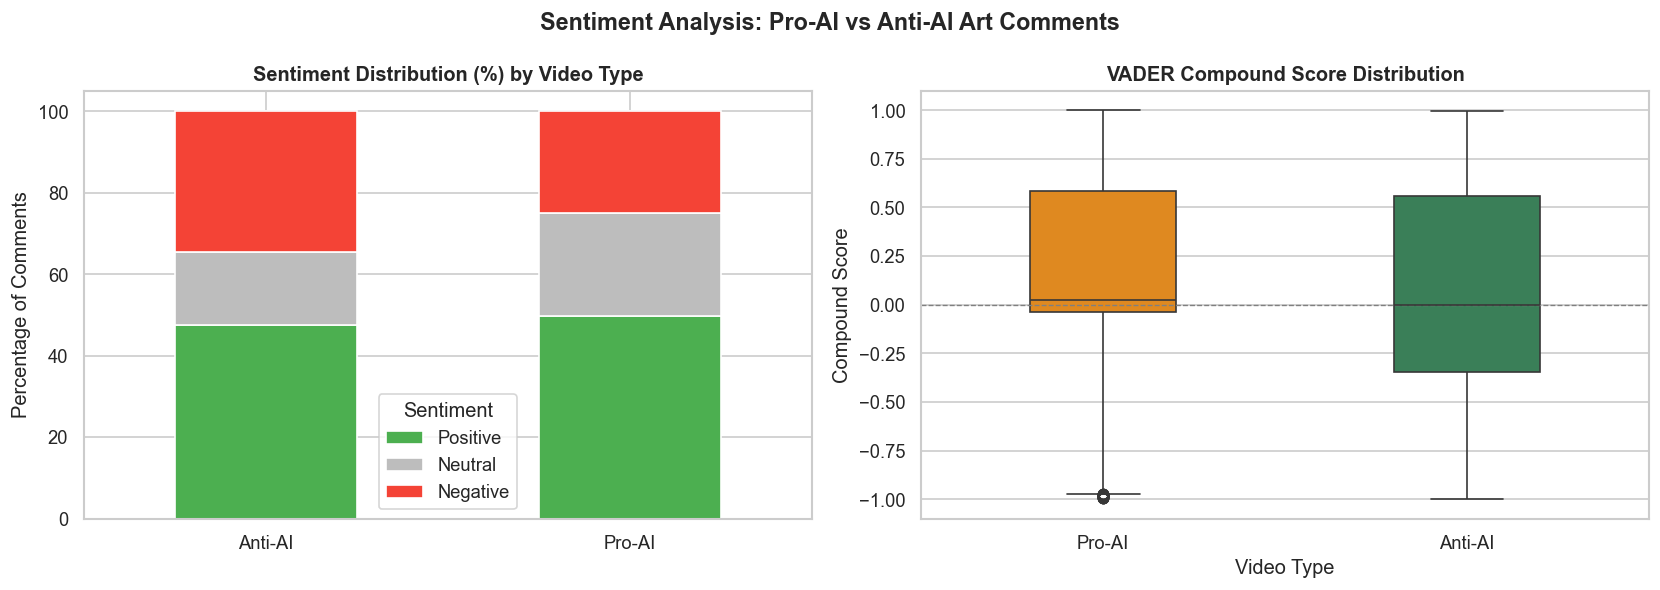

Saved: sentiment_ai_vs_human.png


In [10]:
# sentiment distribution by video type
sent_counts = (
    df.groupby(['video_type', 'sentiment_label'])
    .size()
    .reset_index(name='count')
)
sent_pct = sent_counts.copy()
totals = sent_pct.groupby('video_type')['count'].transform('sum')
sent_pct['pct'] = sent_pct['count'] / totals * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar — percentage
pivot = sent_pct.pivot(index='video_type', columns='sentiment_label', values='pct').fillna(0)
pivot = pivot[['Positive', 'Neutral', 'Negative']]  # consistent order
pivot.plot(kind='bar', stacked=True, ax=axes[0],
           color=['#4caf50', '#bdbdbd', '#f44336'], edgecolor='white', width=0.5)
axes[0].set_title('Sentiment Distribution (%) by Video Type', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Percentage of Comments')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Sentiment')

# Box plot — compound score
sns.boxplot(
    data=df, x='video_type', y='vader_compound',
    palette={'Pro-AI': 'darkorange', 'Anti-AI': 'seagreen'},
    width=0.4, ax=axes[1]
)
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_title('VADER Compound Score Distribution', fontweight='bold')
axes[1].set_xlabel('Video Type')
axes[1].set_ylabel('Compound Score')

plt.suptitle('Sentiment Analysis: Pro-AI vs Anti-AI Art Comments', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sentiment_ai_vs_human.png', bbox_inches='tight')
plt.show()
print('Saved: sentiment_ai_vs_human.png')

In [11]:
# deeper sentiment: pos/neu/neg breakdown per group
summary = df.groupby('video_type')[['vader_compound', 'vader_pos', 'vader_neu', 'vader_neg']].agg(
    ['mean', 'median', 'std']
).round(4)
print('Sentiment summary statistics:')
print(summary)

Sentiment summary statistics:
           vader_compound                 vader_pos                vader_neu  \
                     mean  median     std      mean median     std      mean   
video_type                                                                     
Anti-AI            0.0936  0.0000  0.5427    0.1241  0.093  0.1465    0.7813   
Pro-AI             0.1675  0.0258  0.4867    0.1374  0.093  0.1722    0.7858   

                          vader_neg                 
           median     std      mean median     std  
video_type                                          
Anti-AI     0.803  0.1706    0.0947   0.06  0.1202  
Pro-AI      0.811  0.1938    0.0767   0.00  0.1267  


In [12]:
# statistical test: Mann-Whitney U for compound scores
from scipy import stats

proai_scores    = df.loc[df['video_type'] == 'Pro-AI',    'vader_compound']
antiai_scores = df.loc[df['video_type'] == 'Anti-AI', 'vader_compound']

stat, p = stats.mannwhitneyu(proai_scores, antiai_scores, alternative='two-sided')
print(f'Mann-Whitney U test: statistic={stat:.2f}, p-value={p:.4f}')
if p < 0.05:
    print('Statistically significant difference in sentiment between Pro-AI and Anti-AI video comments (p < 0.05).')
else:
    print('No statistically significant difference detected (p ≥ 0.05).')

Mann-Whitney U test: statistic=50161088.00, p-value=0.0000
Statistically significant difference in sentiment between Pro-AI and Anti-AI video comments (p < 0.05).


---
## 4. LDA Topic Modelling with Sklearn Perplexity Tuning


In [13]:
# lda topic modeling
cv = CountVectorizer(
    max_df=0.85,
    min_df=10,
    ngram_range=(1, 2),
    max_features=8000
)
X = cv.fit_transform(df['cleaned'])
vocab = cv.get_feature_names_out()

print(f'Vocabulary size: {len(vocab):,} terms')
print(f'Document-term matrix shape: {X.shape}')

Vocabulary size: 4,767 terms
Document-term matrix shape: (19334, 4767)


In [14]:
# topic coherence proxy using NPMI on the document-term matrix
from itertools import combinations

K_RANGE = range(2, 11)
perplexity_scores = []
coherence_proxy_scores = []


def sklearn_coherence_proxy(lda_model, dtm, feature_names, top_n=10):
    X_arr = (dtm > 0).astype(int)   
    n_docs = X_arr.shape[0]

    topic_scores = []
    for component in lda_model.components_:
        top_idx = component.argsort()[-top_n:][::-1]

        pair_scores = []
        for i, j in combinations(top_idx, 2):
            # document frequency of each word
            p_i = X_arr[:, i].sum() / n_docs
            p_j = X_arr[:, j].sum() / n_docs
            # joint document frequency
            p_ij = X_arr[:, i].multiply(X_arr[:, j]).sum() / n_docs

            if p_ij > 0 and p_i > 0 and p_j > 0:
                pmi  = np.log(p_ij / (p_i * p_j))
                npmi = pmi / (-np.log(p_ij))   # normalise to [-1, 1]
                pair_scores.append(npmi)

        topic_scores.append(np.mean(pair_scores) if pair_scores else 0.0)

    return np.mean(topic_scores)


print('Sweeping k=2..10')
for k in K_RANGE:
    lda_k = LatentDirichletAllocation(
        n_components=k,
        random_state=42,
        learning_method='batch',
        max_iter=20
    )
    lda_k.fit(X)

    perp  = lda_k.perplexity(X)
    coher = sklearn_coherence_proxy(lda_k, X, vocab, top_n=10)

    perplexity_scores.append(perp)
    coherence_proxy_scores.append(coher)
    print(f'  k={k:2d}  perplexity={perp:8.2f}  coherence_proxy={coher:.4f}')

# Best k = highest coherence proxy (most semantically distinct topics)
best_k = list(K_RANGE)[np.argmax(coherence_proxy_scores)]
print(f'\nSelected k = {best_k}  (highest coherence proxy)')

Sweeping k=2..10
  k= 2  perplexity= 1820.68  coherence_proxy=0.1944
  k= 3  perplexity= 1832.11  coherence_proxy=0.1931
  k= 4  perplexity= 1866.42  coherence_proxy=0.1964
  k= 5  perplexity= 1881.52  coherence_proxy=0.1857
  k= 6  perplexity= 1883.19  coherence_proxy=0.1791
  k= 7  perplexity= 1897.97  coherence_proxy=0.1838
  k= 8  perplexity= 1921.35  coherence_proxy=0.1810
  k= 9  perplexity= 1938.19  coherence_proxy=0.1836
  k=10  perplexity= 1944.77  coherence_proxy=0.1774

Selected k = 4  (highest coherence proxy)


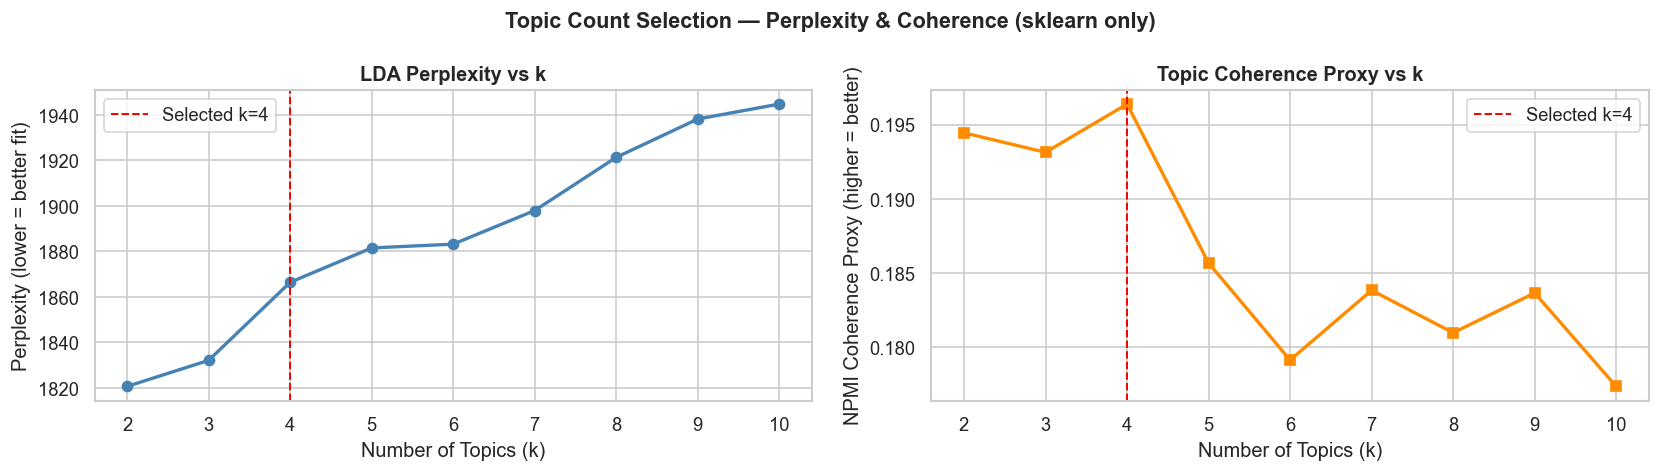

Saved: lda_tuning_curves.png

Final selection: k = 4


In [15]:
# plotting the tuning curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# perplexity (lower = better)
axes[0].plot(list(K_RANGE), perplexity_scores, marker='o', color='steelblue', linewidth=2)
axes[0].axvline(best_k, color='red', linestyle='--', linewidth=1.2, label=f'Selected k={best_k}')
axes[0].set_xlabel('Number of Topics (k)')
axes[0].set_ylabel('Perplexity (lower = better fit)')
axes[0].set_title('LDA Perplexity vs k', fontweight='bold')
axes[0].legend()

# coherence proxy (higher = more distinct topics)
axes[1].plot(list(K_RANGE), coherence_proxy_scores, marker='s', color='darkorange', linewidth=2)
axes[1].axvline(best_k, color='red', linestyle='--', linewidth=1.2, label=f'Selected k={best_k}')
axes[1].set_xlabel('Number of Topics (k)')
axes[1].set_ylabel('NPMI Coherence Proxy (higher = better)')
axes[1].set_title('Topic Coherence Proxy vs k', fontweight='bold')
axes[1].legend()

plt.suptitle('Topic Count Selection — Perplexity & Coherence (sklearn only)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lda_tuning_curves.png', bbox_inches='tight')
plt.show()
print('Saved: lda_tuning_curves.png')
print(f'\nFinal selection: k = {best_k}')

In [16]:
# final LDA model with best k
cv_final = CountVectorizer(
    max_df=0.85, min_df=10,
    ngram_range=(1, 2), max_features=8000
)
X_final = cv_final.fit_transform(df['cleaned'])

lda_final = LatentDirichletAllocation(
    n_components=best_k,
    random_state=42,
    learning_method='batch',
    max_iter=20
)
lda_final.fit(X_final)

print(f'Final LDA model trained: k={best_k} topics')
print(f'Final perplexity: {lda_final.perplexity(X_final):.2f}')

Final LDA model trained: k=4 topics
Final perplexity: 1866.42


In [17]:
# print top words per topic
vocab = cv_final.get_feature_names_out()

def get_top_words(model, feature_names, n=12):
    topics = {}
    for idx, component in enumerate(model.components_):
        top_idx = component.argsort()[-n:][::-1]
        topics[idx] = [feature_names[i] for i in top_idx]
    return topics

topic_words = get_top_words(lda_final, vocab)

print('Top words per LDA topic')
for t, words in topic_words.items():
    print(f'\nTopic {t}: {words}')


Top words per LDA topic

Topic 0: ['artist', 'tool', 'image', 'prompt', 'work', 'real', 'idea', 'used', 'drawing', 'generated', 'process', 'game']

Topic 1: ['art', 'human', 'feel', 'look', 'point', 'argument', 'never', 'bad', 'real', 'hate', 'make', 'life']

Topic 2: ['year', 'job', 'already', 'better', 'work', 'data', 'model', 'need', 'company', 'day', 'point', 'new']

Topic 3: ['art', 'artist', 'work', 'image', 'without', 'someone', 'create', 'skill', 'take', 'human', 'draw', 'put']


In [18]:
TOPIC_LABELS = {
    0: "AI Art Tools",
    1: "Emotional & Ethics Debate",
    2: "Jobs & Impact",
    3: "Human Creativity vs AI"
}
print('Top words per LDA topic')
for t, words in topic_words.items():
    label = TOPIC_LABELS[t]
    print(f'\n{label}: {words}')

Top words per LDA topic

AI Art Tools: ['artist', 'tool', 'image', 'prompt', 'work', 'real', 'idea', 'used', 'drawing', 'generated', 'process', 'game']

Emotional & Ethics Debate: ['art', 'human', 'feel', 'look', 'point', 'argument', 'never', 'bad', 'real', 'hate', 'make', 'life']

Jobs & Impact: ['year', 'job', 'already', 'better', 'work', 'data', 'model', 'need', 'company', 'day', 'point', 'new']

Human Creativity vs AI: ['art', 'artist', 'work', 'image', 'without', 'someone', 'create', 'skill', 'take', 'human', 'draw', 'put']


In [19]:
# assign dominant topic to each comment
topic_dist = lda_final.transform(X_final)
df['topic_id']       = topic_dist.argmax(axis=1)
df['topic_label']    = df['topic_id'].map(TOPIC_LABELS)
df['topic_strength'] = topic_dist.max(axis=1)   # confidence in dominant topic

topic_summary = df.groupby(['topic_id', 'topic_label']).size().reset_index(name='n_comments')
topic_summary['pct'] = (topic_summary['n_comments'] / len(df) * 100).round(1)
print(topic_summary)

   topic_id                topic_label  n_comments   pct
0         0               AI Art Tools        4282  22.1
1         1  Emotional & Ethics Debate        5718  29.6
2         2              Jobs & Impact        5210  26.9
3         3     Human Creativity vs AI        4124  21.3


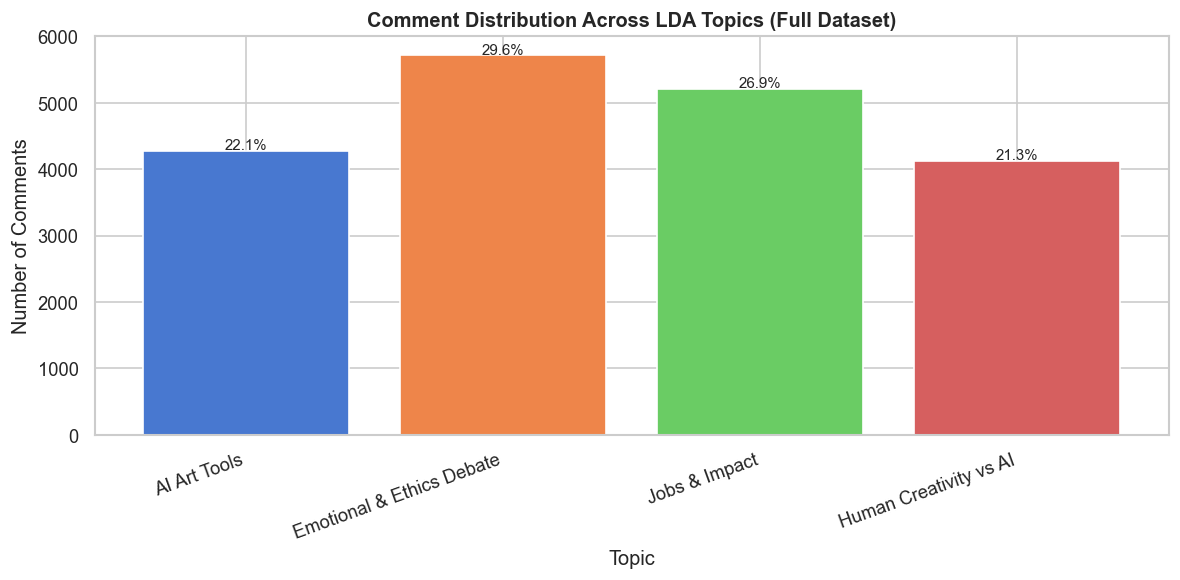

Saved: lda_topic_distribution.png


In [20]:
# topic distribution plot
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    topic_summary['topic_label'],
    topic_summary['n_comments'],
    color=sns.color_palette('muted', len(topic_summary)),
    edgecolor='white'
)
for bar, pct in zip(bars, topic_summary['pct']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f'{pct}%', ha='center', fontsize=9)
ax.set_title('Comment Distribution Across LDA Topics (Full Dataset)', fontweight='bold')
ax.set_xlabel('Topic')
ax.set_ylabel('Number of Comments')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lda_topic_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: lda_topic_distribution.png')

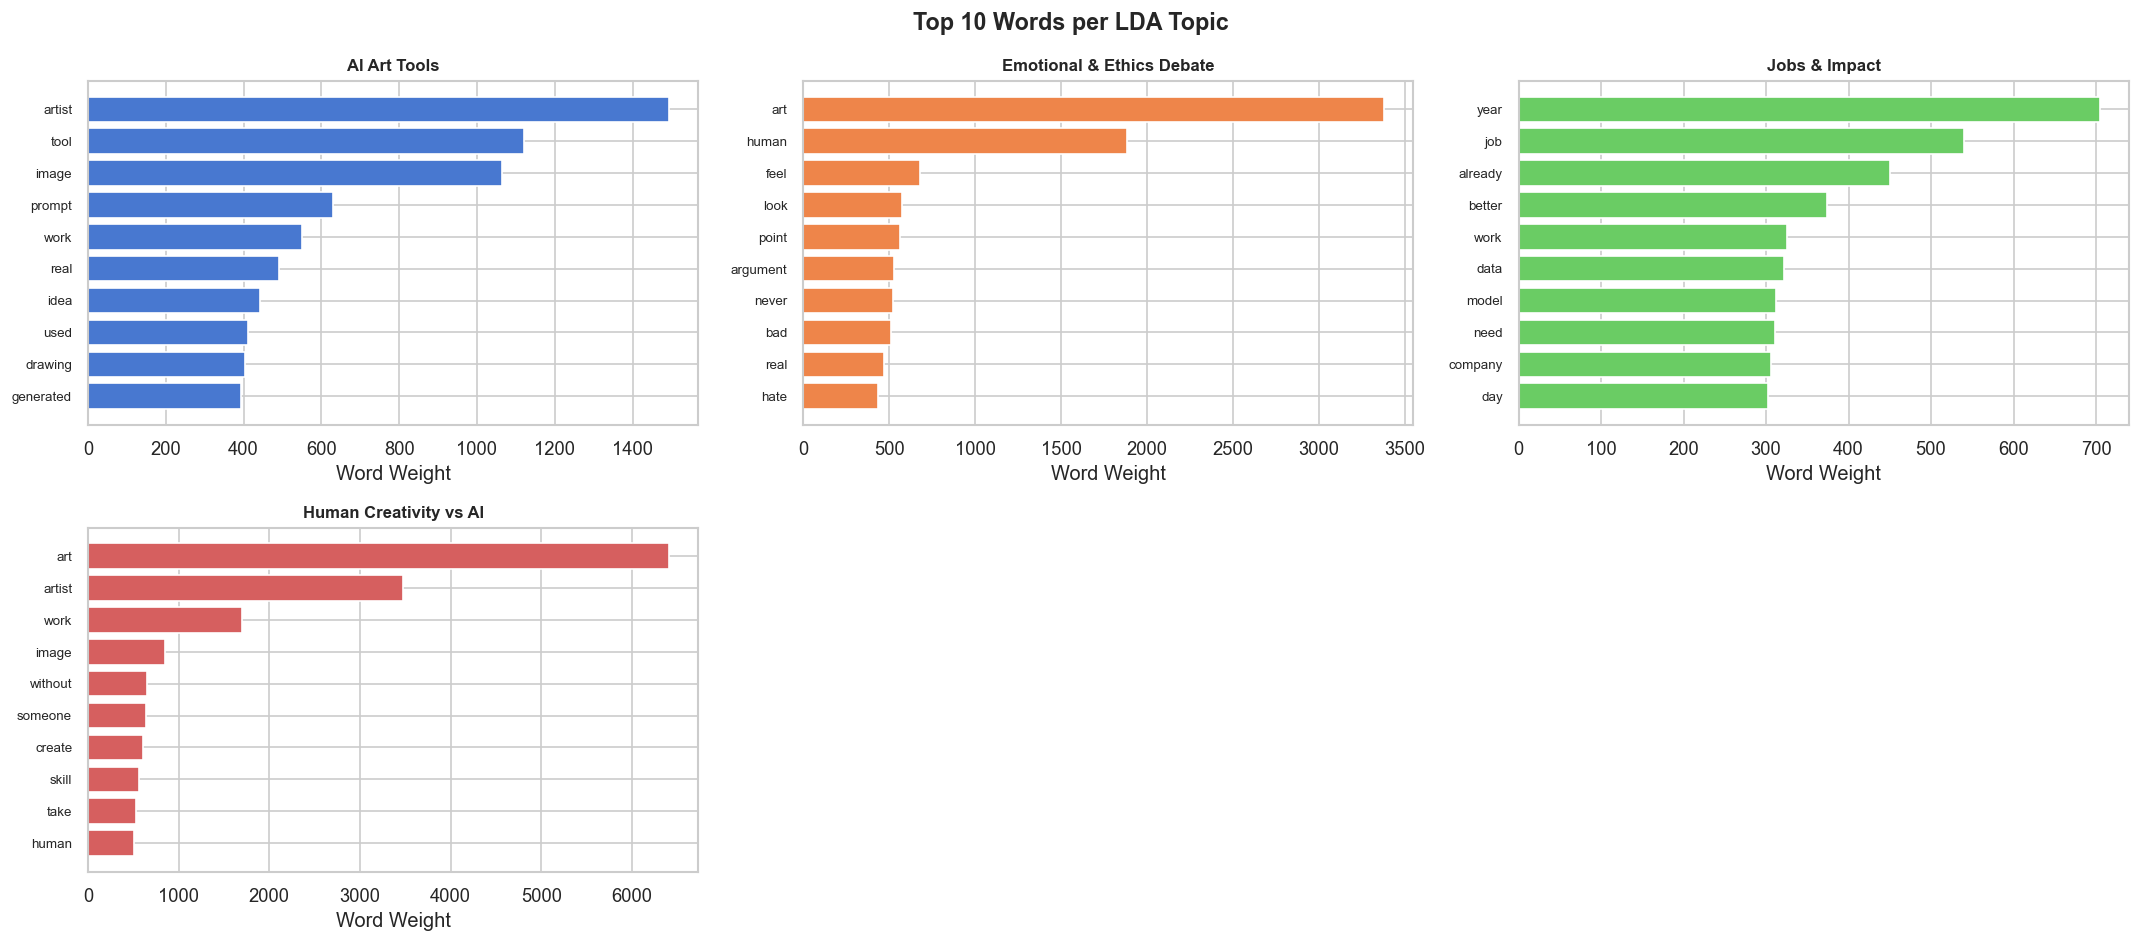

Saved: lda_topic_words.png


In [21]:
# per-topic word importance plots
n_cols = min(best_k, 3)
n_rows = (best_k + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = np.array(axes).flatten()

colors = sns.color_palette('muted', best_k)

for t, ax in enumerate(axes):
    if t >= best_k:
        ax.set_visible(False)
        continue
    words = topic_words[t][:10]
    scores = lda_final.components_[t][[
        list(vocab).index(w) for w in words
    ]]
    ax.barh(words[::-1], scores[::-1], color=colors[t], edgecolor='white')
    ax.set_title(f'{TOPIC_LABELS[t]}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Word Weight')
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Top 10 Words per LDA Topic', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lda_topic_words.png', bbox_inches='tight')
plt.show()
print('Saved: lda_topic_words.png')

---
## 5. Pro-AI vs Anti-AI Comparison: Topics & Sentiment

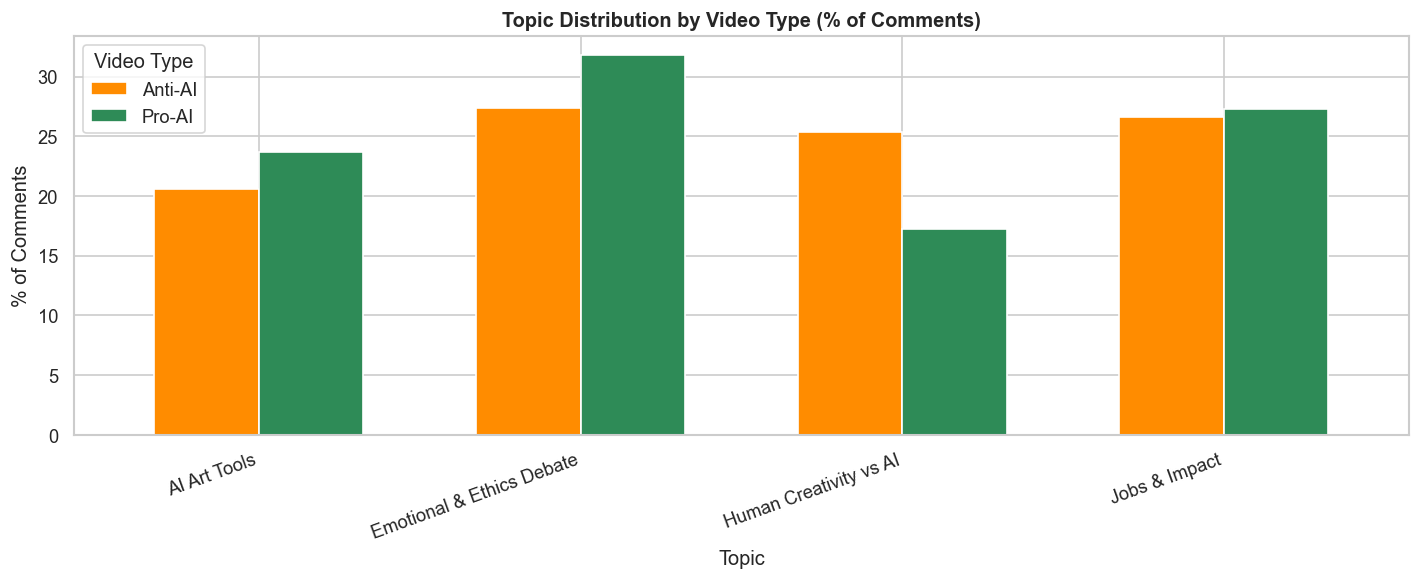

Saved: topic_by_video_type.png


In [22]:
# topic distribution by video type
topic_by_type = (
    df.groupby(['video_type', 'topic_label'])
    .size()
    .reset_index(name='count')
)
totals_by_type = topic_by_type.groupby('video_type')['count'].transform('sum')
topic_by_type['pct'] = topic_by_type['count'] / totals_by_type * 100

pivot_topic = topic_by_type.pivot(index='topic_label', columns='video_type', values='pct').fillna(0)

pivot_topic.plot(
    kind='bar', figsize=(12, 5),
    color=['darkorange', 'seagreen'],
    edgecolor='white', width=0.65
)
plt.title('Topic Distribution by Video Type (% of Comments)', fontweight='bold')
plt.xlabel('Topic')
plt.ylabel('% of Comments')
plt.xticks(rotation=20, ha='right')
plt.legend(title='Video Type')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'topic_by_video_type.png', bbox_inches='tight')
plt.show()
print('Saved: topic_by_video_type.png')

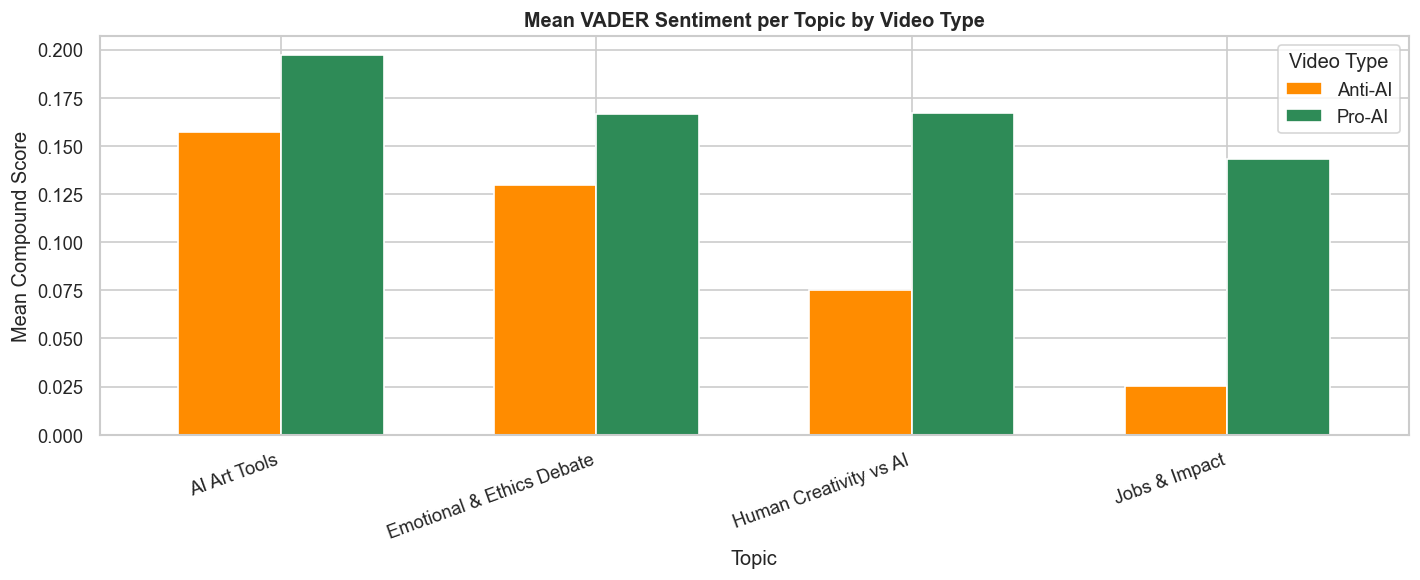

Saved: sentiment_by_topic_and_type.png


In [23]:
# sentiment by topic and video type
sent_topic = (
    df.groupby(['video_type', 'topic_label'])['vader_compound']
    .mean()
    .reset_index(name='mean_sentiment')
)

pivot_sent = sent_topic.pivot(index='topic_label', columns='video_type', values='mean_sentiment')

fig, ax = plt.subplots(figsize=(12, 5))
pivot_sent.plot(kind='bar', ax=ax, color=['darkorange', 'seagreen'], edgecolor='white', width=0.65)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Mean VADER Sentiment per Topic by Video Type', fontweight='bold')
ax.set_xlabel('Topic')
ax.set_ylabel('Mean Compound Score')
ax.tick_params(axis='x', rotation=20)
plt.xticks(ha='right')
plt.legend(title='Video Type')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sentiment_by_topic_and_type.png', bbox_inches='tight')
plt.show()
print('Saved: sentiment_by_topic_and_type.png')

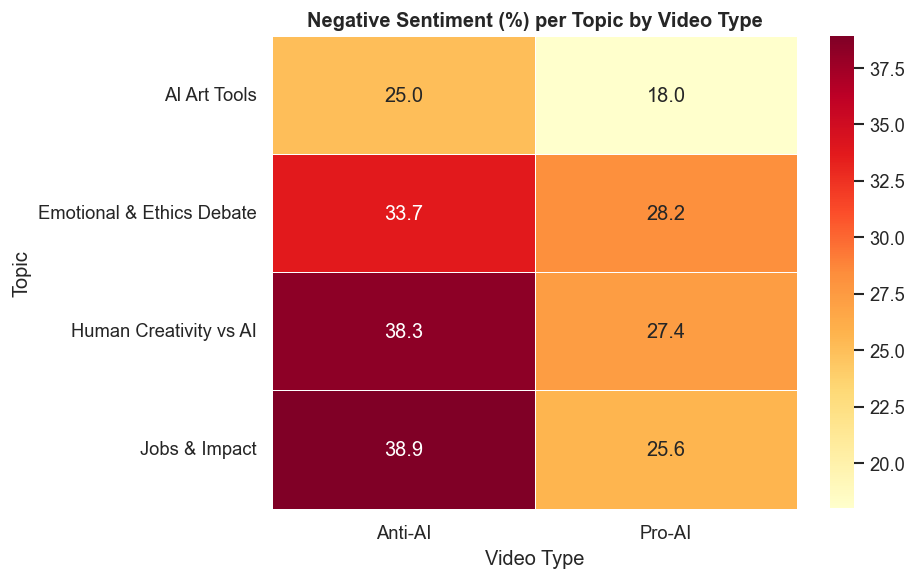

Saved: heatmap_negative_sentiment.png


In [24]:
# heatmap of sentiment distribution across topics and video types
heat_data = (
    df.groupby(['video_type', 'topic_label', 'sentiment_label'])
    .size()
    .reset_index(name='count')
)
heat_totals = heat_data.groupby(['video_type', 'topic_label'])['count'].transform('sum')
heat_data['pct'] = heat_data['count'] / heat_totals * 100

# Focus on negative sentiment as the most informative signal
neg_pivot = heat_data[heat_data['sentiment_label'] == 'Negative'].pivot_table(
    index='topic_label', columns='video_type', values='pct', aggfunc='sum'
).fillna(0)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(neg_pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Negative Sentiment (%) per Topic by Video Type', fontweight='bold')
ax.set_xlabel('Video Type')
ax.set_ylabel('Topic')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'heatmap_negative_sentiment.png', bbox_inches='tight')
plt.show()
print('Saved: heatmap_negative_sentiment.png')

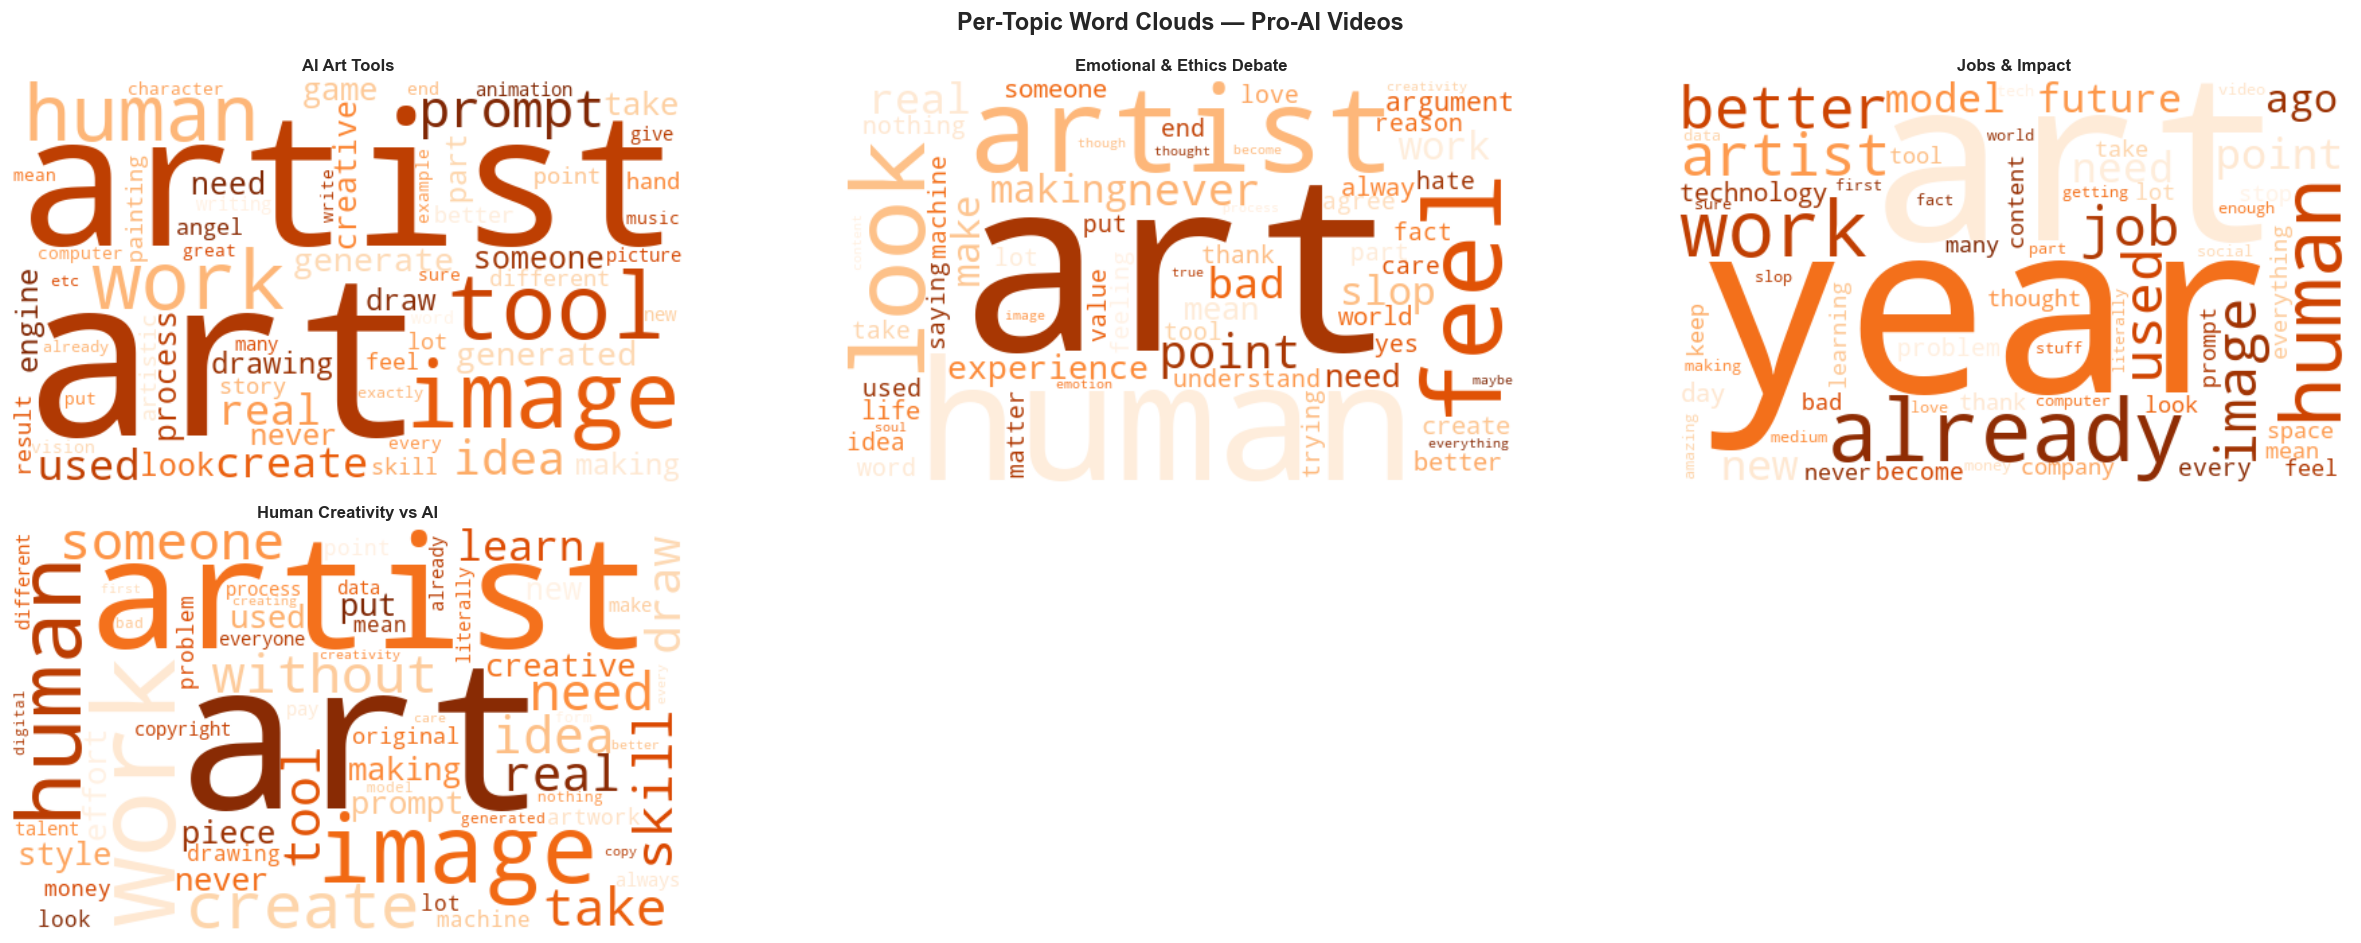

Saved: wordclouds_per_topic_proai.png


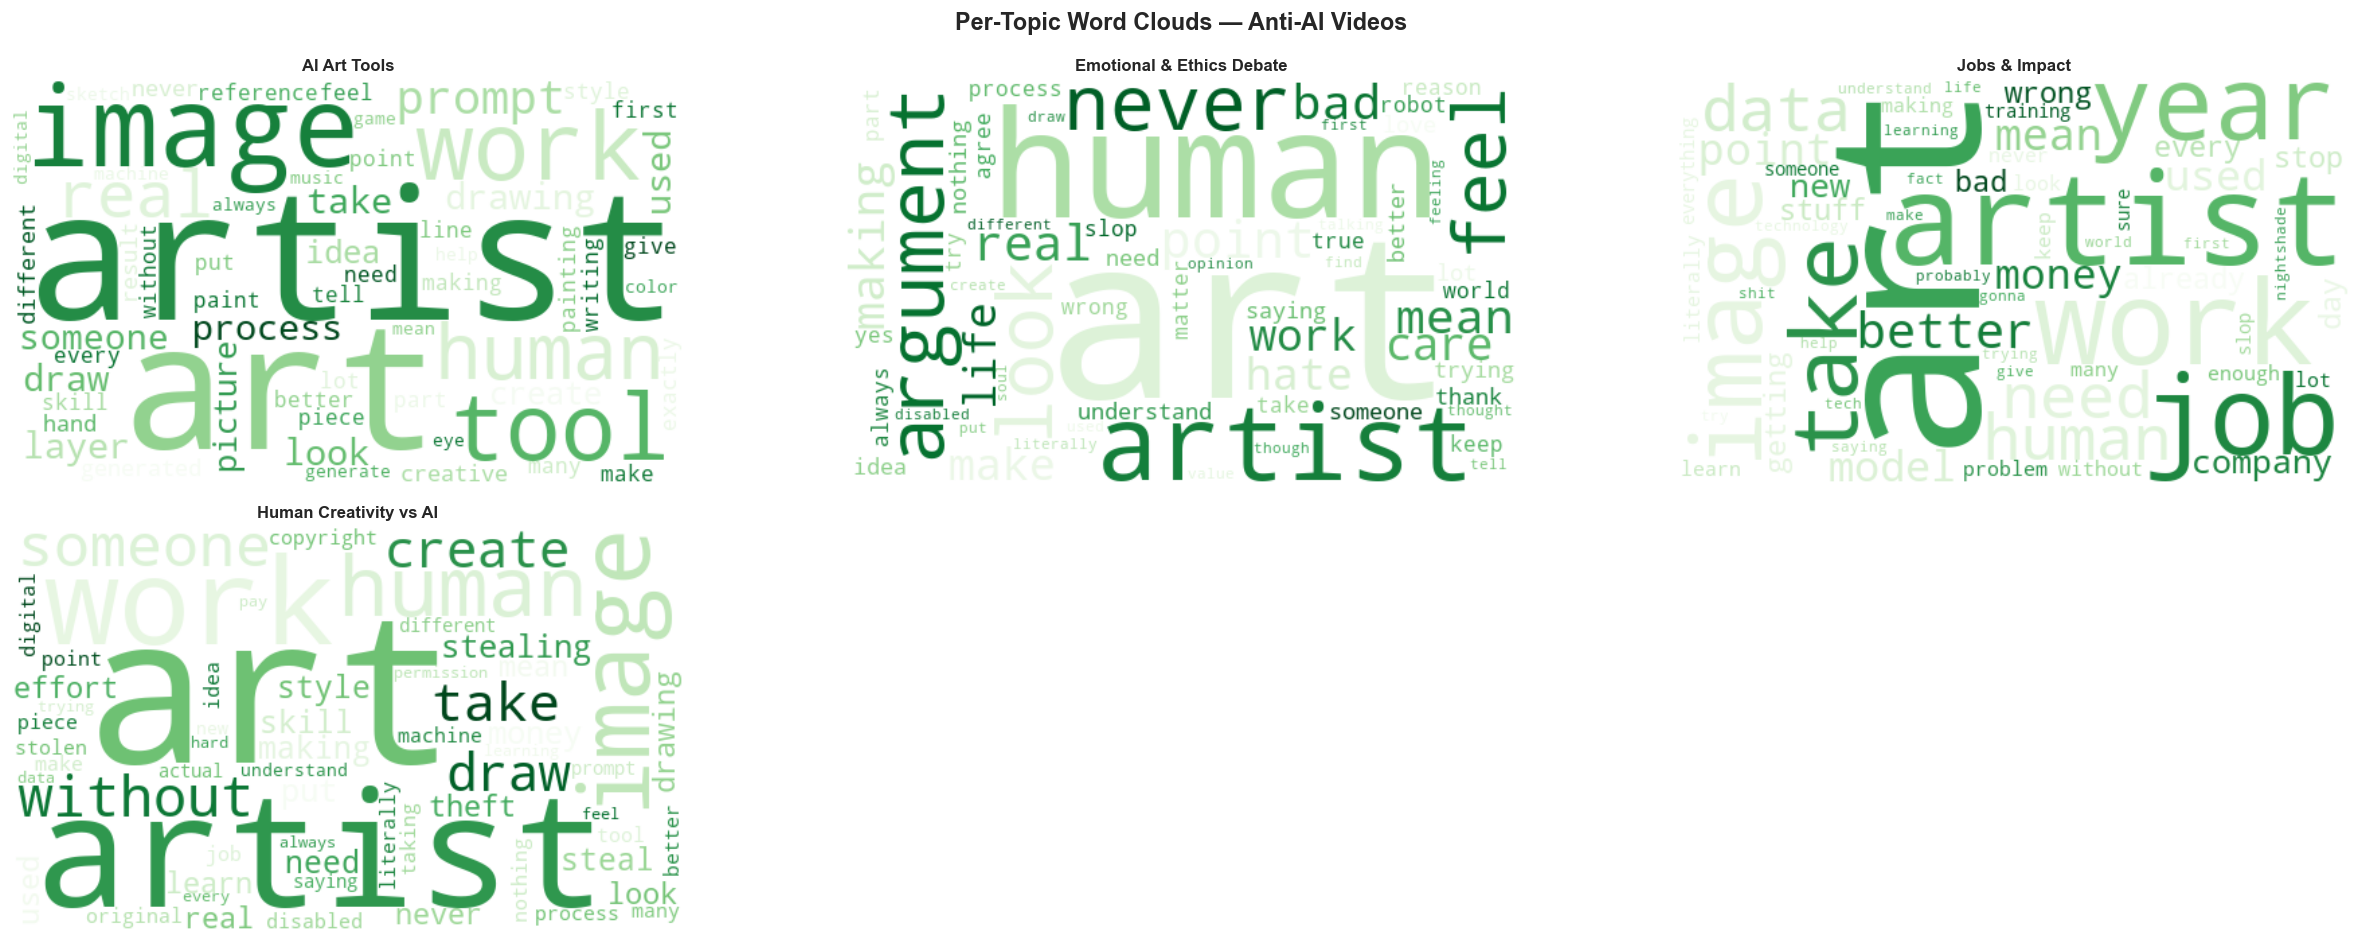

Saved: wordclouds_per_topic_antiai.png


In [25]:
# per-topic word clouds split by video type
for vtype in ['Pro-AI', 'Anti-AI']:
    subset = df[df['video_type'] == vtype]
    n_topics = best_k
    n_cols_wc = min(n_topics, 3)
    n_rows_wc = (n_topics + n_cols_wc - 1) // n_cols_wc

    fig, axes = plt.subplots(n_rows_wc, n_cols_wc, figsize=(7 * n_cols_wc, 4 * n_rows_wc))
    axes = np.array(axes).flatten()

    cmap = 'Oranges' if vtype == 'Pro-AI' else 'Greens'

    for t, ax in enumerate(axes):
        if t >= n_topics:
            ax.set_visible(False)
            continue
        topic_text = ' '.join(subset[subset['topic_id'] == t]['cleaned'])
        if not topic_text.strip():
            ax.set_visible(False)
            continue
        wc = WordCloud(width=500, height=300, background_color='white',
                       colormap=cmap, max_words=60, collocations=False).generate(topic_text)
        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(TOPIC_LABELS[t], fontsize=10, fontweight='bold')

    plt.suptitle(f'Per-Topic Word Clouds — {vtype} Videos', fontsize=14, fontweight='bold')
    plt.tight_layout()
    fname = f"wordclouds_per_topic_{'proai' if vtype == 'Pro-AI' else 'antiai'}.png"
    plt.savefig(OUTPUT_DIR / fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

In [26]:
# summarise everything in a final table
final_summary = (
    df.groupby(['video_type', 'topic_label'])
    .agg(
        n_comments=('vader_compound', 'count'),
        mean_sentiment=('vader_compound', 'mean'),
        pct_positive=('sentiment_label', lambda s: (s == 'Positive').mean() * 100),
        pct_neutral=('sentiment_label',  lambda s: (s == 'Neutral').mean()  * 100),
        pct_negative=('sentiment_label', lambda s: (s == 'Negative').mean() * 100),
    )
    .round(2)
    .reset_index()
)

print('Final Summary: Topic x Sentiment x Video Type')
print(final_summary.to_string(index=False))

Final Summary: Topic x Sentiment x Video Type
video_type               topic_label  n_comments  mean_sentiment  pct_positive  pct_neutral  pct_negative
   Anti-AI              AI Art Tools        2008            0.16         47.81        27.14         25.05
   Anti-AI Emotional & Ethics Debate        2669            0.13         51.44        14.84         33.72
   Anti-AI    Human Creativity vs AI        2472            0.08         47.57        14.12         38.31
   Anti-AI             Jobs & Impact        2594            0.03         42.79        18.31         38.90
    Pro-AI              AI Art Tools        2274            0.20         48.11        33.91         17.99
    Pro-AI Emotional & Ethics Debate        3049            0.17         52.74        19.02         28.24
    Pro-AI    Human Creativity vs AI        1652            0.17         51.21        21.43         27.36
    Pro-AI             Jobs & Impact        2616            0.14         46.90        27.48         25.61
